# 从零实现 Decoder-Only Transformer

本教程从一段文本开始，逐层实现一个可以预测下一个字符并自动生成文本的微型 Transformer。我们会使用 PyTorch 的基础层（`Linear`、`Embedding`、`LayerNorm`），但不会使用 `nn.MultiheadAttention`、`nn.Transformer` 或预训练模型。

参考 [Transformer Explainer](https://poloclub.github.io/transformer-explainer/) 的可视化思路，本教程始终追踪一条主线：

```text
字符 -> token id -> embedding -> causal self-attention
     -> Transformer blocks -> logits -> 下一个字符
```

## 学习目标

完成后，你应该能解释：

- 文本如何变成模型可以处理的 token；
- Query、Key、Value 各自做什么；
- 为什么 attention score 要除以 $\sqrt{d_k}$；
- causal mask 如何阻止模型偷看未来 token；
- 多头注意力如何拆分和合并张量；
- 残差连接、LayerNorm 和前馈网络如何组成 Transformer block；
- 训练时为何可以并行预测所有位置，生成时却必须逐 token 进行。

> 这是教学模型，不追求生成质量。它使用字符级 tokenizer、内置短文本和很小的网络，目标是让每个计算步骤都可检查。

## 1. 环境与实验配置

为便于复现，我们固定随机种子。默认使用 CPU；将 `use_accelerator` 改为 `True` 后，代码会优先选择 CUDA，其次选择 Apple Silicon 的 MPS。

核心形状符号：

| 符号 | 含义 |
|---|---|
| `B` | batch size，一批有多少段文本 |
| `T` | sequence length，每段文本有多少个 token |
| `C` | embedding dimension，每个 token 的向量维度 |
| `H` | attention head 数量 |
| `D=C/H` | 每个 head 的维度 |

In [1]:
import math
import random
from contextlib import nullcontext

import matplotlib.pyplot as plt
import torch
from torch import nn
import torch.nn.functional as F

seed = 42
random.seed(seed)
torch.manual_seed(seed)

use_accelerator = False
if use_accelerator and torch.cuda.is_available():
    device = torch.device("cuda")
elif use_accelerator and torch.backends.mps.is_available():
    device = torch.device("mps")
else:
    device = torch.device("cpu")

print("PyTorch:", torch.__version__)
print("device:", device)

PyTorch: 2.8.0.dev20250525
device: cpu


## 2. 内置语料与字符级 tokenizer

语言模型学习条件概率：

$$P(x_t \mid x_1, x_2, \ldots, x_{t-1})$$

也就是根据前面的 token 预测下一个 token。这里一个 token 就是一个字符，包括字母、空格和标点。

字符级 tokenizer 的优点是实现透明、没有未知单词；缺点是序列更长，语义单位也比词或子词弱。实际大模型通常使用 BPE 或类似的子词 tokenizer。

In [2]:
base_text = """
the little model reads the words and learns the rhythm.
attention lets each token look back at the tokens before it.
the moon is bright, the night is calm, and the river moves slowly.
we build the transformer one careful step at a time.
when the model predicts a character, the story grows by one.
""".strip()

# 重复短语料以得到足够多的训练窗口；不需要网络下载。
text = ((base_text + "\n") * 80).strip()
chars = sorted(set(text))
vocab_size = len(chars)
stoi = {ch: i for i, ch in enumerate(chars)}
itos = {i: ch for ch, i in stoi.items()}

def encode(value: str) -> list[int]:
    unknown = sorted(set(value) - set(stoi))
    if unknown:
        raise ValueError(f"unknown characters: {unknown}")
    return [stoi[ch] for ch in value]

def decode(token_ids) -> str:
    ids = token_ids.tolist() if isinstance(token_ids, torch.Tensor) else token_ids
    try:
        return "".join(itos[int(i)] for i in ids)
    except KeyError as exc:
        raise ValueError(f"unknown token id: {exc.args[0]}") from exc

sample = "attention"
sample_ids = encode(sample)
assert decode(sample_ids) == sample

print("corpus characters:", len(text))
print("vocabulary size:", vocab_size)
print("vocabulary:", repr("".join(chars)))
print("encode:", sample, "->", sample_ids)
print("decode:", decode(sample_ids))

corpus characters: 23839
vocabulary size: 26
vocabulary: '\n ,.abcdefghiklmnoprstuvwy'
encode: attention -> [4, 21, 21, 8, 16, 21, 12, 17, 16]
decode: attention


### 从 token id 到训练数据

把完整文本编码为一维整数张量，再按 90%/10% 划分训练集和验证集。验证集不参与参数更新，只用于判断模型是否能泛化到未用于更新的文本位置。

`block_size=48` 表示模型一次最多看到 48 个字符。对长度为 49 的片段：

```text
输入 x:  token[0], token[1], ..., token[47]
目标 y:  token[1], token[2], ..., token[48]
```

`y` 相对 `x` 左移一位，所以一个长度为 48 的样本同时提供 48 个“预测下一个字符”的训练目标。

In [3]:
data = torch.tensor(encode(text), dtype=torch.long)
split_index = int(0.9 * len(data))
train_data = data[:split_index]
val_data = data[split_index:]

batch_size = 32
block_size = 48

def get_batch(split: str) -> tuple[torch.Tensor, torch.Tensor]:
    if split not in {"train", "val"}:
        raise ValueError("split must be 'train' or 'val'")
    source = train_data if split == "train" else val_data
    if len(source) <= block_size:
        raise ValueError("dataset is shorter than block_size + 1")
    starts = torch.randint(0, len(source) - block_size, (batch_size,))
    x = torch.stack([source[i:i + block_size] for i in starts])
    y = torch.stack([source[i + 1:i + block_size + 1] for i in starts])
    return x.to(device), y.to(device)

xb, yb = get_batch("train")
assert xb.shape == yb.shape == (batch_size, block_size)
assert torch.equal(xb[:, 1:], yb[:, :-1])

print("x shape:", tuple(xb.shape))
print("y shape:", tuple(yb.shape))
print("input :", repr(decode(xb[0, :30].cpu())))
print("target:", repr(decode(yb[0, :30].cpu())))

x shape: (32, 48)
y shape: (32, 48)
input : '\nwe build the transformer one '
target: 'we build the transformer one c'


## 3. Embedding：把离散 token 变成连续向量

token id 只是一个类别编号，编号的大小没有语义距离。`nn.Embedding` 可以理解为一张可训练的查找表：给定 token id，取出对应的一行向量。

Decoder-only Transformer 使用两类 embedding：

1. **Token embedding**：表示“这是哪个字符”；
2. **Position embedding**：表示“这个字符位于序列的什么位置”。

两者形状相同，因此直接相加：

$$x_{b,t}=E_{token}[id_{b,t}]+E_{position}[t]$$

注意力本身不包含顺序概念。如果没有位置信息，交换两个 token 后，模型无法可靠区分它们的先后关系。

In [4]:
n_embd = 64
token_embedding_demo = nn.Embedding(vocab_size, n_embd).to(device)
position_embedding_demo = nn.Embedding(block_size, n_embd).to(device)

B, T = xb.shape
token_vectors = token_embedding_demo(xb)
position_ids = torch.arange(T, device=device)
position_vectors = position_embedding_demo(position_ids)
embedded = token_vectors + position_vectors

assert token_vectors.shape == (B, T, n_embd)
assert position_vectors.shape == (T, n_embd)
assert embedded.shape == (B, T, n_embd)

print("token ids:       ", tuple(xb.shape))
print("token embedding: ", tuple(token_vectors.shape))
print("position vectors:", tuple(position_vectors.shape))
print("combined:        ", tuple(embedded.shape))

token ids:        (32, 48)
token embedding:  (32, 48, 64)
position vectors: (48, 64)
combined:         (32, 48, 64)


## 4. Scaled Dot-Product Attention

每个 token 向量分别经过三个线性投影，得到 Query、Key、Value：

$$Q=XW_Q,\qquad K=XW_K,\qquad V=XW_V$$

可以用“检索”建立直觉：

- **Query**：当前位置正在寻找什么信息；
- **Key**：每个位置提供什么匹配线索；
- **Value**：匹配后真正取回的内容。

Query 和所有 Key 做点积，得到 token 两两之间的相关性：

$$S=\frac{QK^T}{\sqrt{d_k}}$$

维度越大，点积的绝对值通常越大，softmax 越容易饱和。除以 $\sqrt{d_k}$ 能稳定分数尺度和梯度。softmax 把每一行变成和为 1 的注意力权重，最后对 Value 加权求和：

$$A=\operatorname{softmax}(S),\qquad O=AV$$

In [5]:
# 用一个很小的张量观察注意力矩阵。
B_demo, T_demo, D_demo = 1, 4, 8
q_demo = torch.randn(B_demo, T_demo, D_demo)
k_demo = torch.randn(B_demo, T_demo, D_demo)
v_demo = torch.randn(B_demo, T_demo, D_demo)

scores_demo = q_demo @ k_demo.transpose(-2, -1) / math.sqrt(D_demo)
weights_demo = F.softmax(scores_demo, dim=-1)
output_demo = weights_demo @ v_demo

assert scores_demo.shape == (B_demo, T_demo, T_demo)
assert torch.allclose(weights_demo.sum(dim=-1), torch.ones(B_demo, T_demo))

print("Q:", tuple(q_demo.shape))
print("Q @ K^T:", tuple(scores_demo.shape))
print("attention @ V:", tuple(output_demo.shape))
print("row sums:", weights_demo.sum(dim=-1))

Q: (1, 4, 8)
Q @ K^T: (1, 4, 4)
attention @ V: (1, 4, 8)
row sums: tensor([[1.0000, 1.0000, 1.0000, 1.0000]])


## 5. Causal Mask：禁止偷看未来

训练时，我们一次把整段序列送入模型，以便并行预测每个位置。但预测位置 $t$ 时，只能读取位置 $0\ldots t$，不能读取未来的正确答案。

下三角 mask 表示允许访问的位置：

```text
query 0: [可看, 禁止, 禁止, 禁止]
query 1: [可看, 可看, 禁止, 禁止]
query 2: [可看, 可看, 可看, 禁止]
query 3: [可看, 可看, 可看, 可看]
```

在 softmax **之前**，把禁止位置的 score 替换为 $-\infty$。这些位置经过 softmax 后概率变成 0。

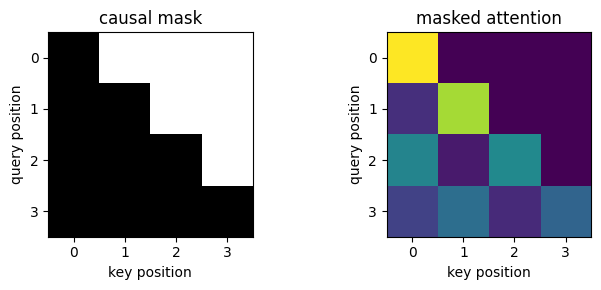

In [6]:
causal_mask_demo = torch.tril(torch.ones(T_demo, T_demo, dtype=torch.bool))
masked_scores_demo = scores_demo.masked_fill(~causal_mask_demo, float("-inf"))
causal_weights_demo = F.softmax(masked_scores_demo, dim=-1)

assert torch.all(causal_weights_demo[..., ~causal_mask_demo] == 0)
assert torch.allclose(causal_weights_demo.sum(dim=-1), torch.ones(B_demo, T_demo))

fig, axes = plt.subplots(1, 2, figsize=(7, 3))
axes[0].imshow(causal_mask_demo, cmap="Greys", vmin=0, vmax=1)
axes[0].set_title("causal mask")
axes[1].imshow(causal_weights_demo[0], cmap="viridis", vmin=0, vmax=1)
axes[1].set_title("masked attention")
for ax in axes:
    ax.set_xlabel("key position")
    ax.set_ylabel("query position")
plt.tight_layout()
plt.show()

## 6. 从零实现多头因果自注意力

单头注意力只有一种匹配空间。多头注意力把 `C` 维向量拆成 `H` 组，每组独立计算注意力：

```text
(B, T, C)
   -> reshape + transpose
(B, H, T, D), 其中 D = C / H
   -> 每个 head 计算 attention
(B, H, T, D)
   -> transpose + reshape
(B, T, C)
```

这里用一次 `Linear(C, 3C)` 同时计算 Q、K、V，再用 `chunk(3)` 分开。这和使用三个独立线性层数学等价，但计算更集中。

In [7]:
class CausalSelfAttention(nn.Module):
    def __init__(self, n_embd: int, n_head: int, block_size: int, dropout: float):
        super().__init__()
        if n_embd % n_head != 0:
            raise ValueError("n_embd must be divisible by n_head")
        self.n_embd = n_embd
        self.n_head = n_head
        self.head_dim = n_embd // n_head
        self.qkv = nn.Linear(n_embd, 3 * n_embd, bias=False)
        self.projection = nn.Linear(n_embd, n_embd)
        self.attention_dropout = nn.Dropout(dropout)
        self.residual_dropout = nn.Dropout(dropout)
        mask = torch.tril(torch.ones(block_size, block_size, dtype=torch.bool))
        self.register_buffer("causal_mask", mask.view(1, 1, block_size, block_size))

    def forward(self, x: torch.Tensor, return_attention: bool = False):
        B, T, C = x.shape
        if C != self.n_embd:
            raise ValueError(f"expected embedding dimension {self.n_embd}, got {C}")
        if T > self.causal_mask.size(-1):
            raise ValueError("sequence length exceeds configured block_size")

        q, k, v = self.qkv(x).chunk(3, dim=-1)
        q = q.view(B, T, self.n_head, self.head_dim).transpose(1, 2)
        k = k.view(B, T, self.n_head, self.head_dim).transpose(1, 2)
        v = v.view(B, T, self.n_head, self.head_dim).transpose(1, 2)

        scores = q @ k.transpose(-2, -1) / math.sqrt(self.head_dim)
        mask = self.causal_mask[:, :, :T, :T]
        scores = scores.masked_fill(~mask, float("-inf"))
        attention = F.softmax(scores, dim=-1)
        dropped_attention = self.attention_dropout(attention)

        out = dropped_attention @ v
        out = out.transpose(1, 2).contiguous().view(B, T, C)
        out = self.residual_dropout(self.projection(out))
        return (out, attention) if return_attention else out

### 注意力实现检查点

下面检查三个最重要的不变量：

1. 输入和输出形状都是 `(B,T,C)`；
2. attention 形状是 `(B,H,T,T)`；
3. 未来位置概率为 0，每一行概率和为 1。

检查时切换到 `eval()`，避免 attention dropout 让参与输出计算的权重行和发生变化。函数返回的是 dropout 前的权重，便于解释和可视化。

In [8]:
n_head = 4
dropout = 0.1
attention_demo = CausalSelfAttention(n_embd, n_head, block_size, dropout).to(device)
attention_demo.eval()

demo_x = torch.randn(2, 6, n_embd, device=device)
with torch.inference_mode():
    demo_out, demo_attention = attention_demo(demo_x, return_attention=True)

future_positions = torch.triu(torch.ones(6, 6, dtype=torch.bool, device=device), diagonal=1)
assert demo_out.shape == demo_x.shape
assert demo_attention.shape == (2, n_head, 6, 6)
assert torch.all(demo_attention[..., future_positions] == 0)
assert torch.allclose(
    demo_attention.sum(dim=-1),
    torch.ones(2, n_head, 6, device=device),
    atol=1e-6,
)

print("input/output:", tuple(demo_x.shape), "->", tuple(demo_out.shape))
print("attention:", tuple(demo_attention.shape))
print("head dimension:", attention_demo.head_dim)

input/output: (2, 6, 64) -> (2, 6, 64)
attention: (2, 4, 6, 6)
head dimension: 16


## 7. Feed-Forward Network、残差连接与 LayerNorm

注意力负责在不同 token 之间交换信息；前馈网络则对每个 token **独立地**进行相同的非线性变换：

$$\operatorname{FFN}(x)=W_2\,\operatorname{GELU}(W_1x+b_1)+b_2$$

中间维度通常扩展为 embedding 维度的 4 倍，再投影回来。

本教程采用现代 decoder 模型常见的 **pre-norm** block：

$$x \leftarrow x+\operatorname{Attention}(\operatorname{LN}(x))$$

$$x \leftarrow x+\operatorname{FFN}(\operatorname{LN}(x))$$

- **残差连接**提供信息和梯度的直接通路；
- **LayerNorm**稳定每个 token 向量的数值尺度；
- **Dropout**训练时随机丢弃部分激活，缓解过拟合，评估时自动关闭。

In [9]:
class FeedForward(nn.Module):
    def __init__(self, n_embd: int, dropout: float):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(n_embd, 4 * n_embd),
            nn.GELU(),
            nn.Linear(4 * n_embd, n_embd),
            nn.Dropout(dropout),
        )

    def forward(self, x: torch.Tensor) -> torch.Tensor:
        return self.net(x)


class TransformerBlock(nn.Module):
    def __init__(self, n_embd: int, n_head: int, block_size: int, dropout: float):
        super().__init__()
        self.ln1 = nn.LayerNorm(n_embd)
        self.attention = CausalSelfAttention(n_embd, n_head, block_size, dropout)
        self.ln2 = nn.LayerNorm(n_embd)
        self.feed_forward = FeedForward(n_embd, dropout)

    def forward(self, x: torch.Tensor, return_attention: bool = False):
        if return_attention:
            attention_out, weights = self.attention(
                self.ln1(x), return_attention=True
            )
            x = x + attention_out
            x = x + self.feed_forward(self.ln2(x))
            return x, weights
        x = x + self.attention(self.ln1(x))
        x = x + self.feed_forward(self.ln2(x))
        return x


block_demo = TransformerBlock(n_embd, n_head, block_size, dropout).to(device)
block_output = block_demo(torch.randn(2, 10, n_embd, device=device))
assert block_output.shape == (2, 10, n_embd)
print("Transformer block:", (2, 10, n_embd), "->", tuple(block_output.shape))

Transformer block: (2, 10, 64) -> (2, 10, 64)


## 8. 组装完整 Decoder-Only Transformer

完整数据流如下：

```text
idx (B,T)
 -> token embedding + position embedding
x (B,T,C)
 -> TransformerBlock × n_layer
x (B,T,C)
 -> final LayerNorm
 -> language model head
logits (B,T,vocab_size)
```

每个位置的 logits 都是对下一个字符的未归一化分数。训练时将 `(B,T,vocab_size)` 展平为 `(B*T,vocab_size)`，与 `(B*T,)` 的 targets 一起送入交叉熵。

`return_attention=True` 用于教学检查，会收集每一层的 attention 权重；正常训练时不收集，避免保留不必要的数据。

In [10]:
class DecoderOnlyTransformer(nn.Module):
    def __init__(
        self,
        vocab_size: int,
        block_size: int,
        n_embd: int,
        n_head: int,
        n_layer: int,
        dropout: float,
    ):
        super().__init__()
        self.vocab_size = vocab_size
        self.block_size = block_size
        self.token_embedding = nn.Embedding(vocab_size, n_embd)
        self.position_embedding = nn.Embedding(block_size, n_embd)
        self.dropout = nn.Dropout(dropout)
        self.blocks = nn.ModuleList([
            TransformerBlock(n_embd, n_head, block_size, dropout)
            for _ in range(n_layer)
        ])
        self.final_norm = nn.LayerNorm(n_embd)
        self.lm_head = nn.Linear(n_embd, vocab_size, bias=False)
        self.apply(self._init_weights)

    @staticmethod
    def _init_weights(module):
        if isinstance(module, nn.Linear):
            nn.init.normal_(module.weight, mean=0.0, std=0.02)
            if module.bias is not None:
                nn.init.zeros_(module.bias)
        elif isinstance(module, nn.Embedding):
            nn.init.normal_(module.weight, mean=0.0, std=0.02)

    def forward(self, idx, targets=None, return_attention=False):
        if idx.dtype != torch.long:
            raise TypeError("idx must contain torch.long token ids")
        B, T = idx.shape
        if T > self.block_size:
            raise ValueError("sequence length exceeds block_size")
        if targets is not None and targets.shape != idx.shape:
            raise ValueError("targets must have the same shape as idx")

        positions = torch.arange(T, device=idx.device)
        x = self.token_embedding(idx) + self.position_embedding(positions)
        x = self.dropout(x)

        attentions = []
        for block in self.blocks:
            if return_attention:
                x, weights = block(x, return_attention=True)
                attentions.append(weights)
            else:
                x = block(x)

        logits = self.lm_head(self.final_norm(x))
        loss = None
        if targets is not None:
            loss = F.cross_entropy(
                logits.reshape(B * T, self.vocab_size),
                targets.reshape(B * T),
            )
        return logits, loss, attentions

### 完整模型检查点

这个单元不会训练，只验证接口契约：logits 形状正确、损失为有限标量、每层都能返回一个多头注意力矩阵。

In [11]:
n_layer = 2
model = DecoderOnlyTransformer(
    vocab_size=vocab_size,
    block_size=block_size,
    n_embd=n_embd,
    n_head=n_head,
    n_layer=n_layer,
    dropout=dropout,
).to(device)

logits, initial_batch_loss, attention_layers = model(
    xb, yb, return_attention=True
)
parameter_count = sum(parameter.numel() for parameter in model.parameters())

assert logits.shape == (batch_size, block_size, vocab_size)
assert initial_batch_loss.ndim == 0 and torch.isfinite(initial_batch_loss)
assert len(attention_layers) == n_layer
assert attention_layers[0].shape == (batch_size, n_head, block_size, block_size)

print(model)
print(f"parameters: {parameter_count:,}")
print("logits:", tuple(logits.shape))
print("loss:", initial_batch_loss.item())

DecoderOnlyTransformer(
  (token_embedding): Embedding(26, 64)
  (position_embedding): Embedding(48, 64)
  (dropout): Dropout(p=0.1, inplace=False)
  (blocks): ModuleList(
    (0-1): 2 x TransformerBlock(
      (ln1): LayerNorm((64,), eps=1e-05, elementwise_affine=True)
      (attention): CausalSelfAttention(
        (qkv): Linear(in_features=64, out_features=192, bias=False)
        (projection): Linear(in_features=64, out_features=64, bias=True)
        (attention_dropout): Dropout(p=0.1, inplace=False)
        (residual_dropout): Dropout(p=0.1, inplace=False)
      )
      (ln2): LayerNorm((64,), eps=1e-05, elementwise_affine=True)
      (feed_forward): FeedForward(
        (net): Sequential(
          (0): Linear(in_features=64, out_features=256, bias=True)
          (1): GELU(approximate='none')
          (2): Linear(in_features=256, out_features=64, bias=True)
          (3): Dropout(p=0.1, inplace=False)
        )
      )
    )
  )
  (final_norm): LayerNorm((64,), eps=1e-05, elem

## 9. 训练：让模型预测下一个字符

训练循环使用 `AdamW`。每次更新的执行顺序仍然是 PyTorch 的标准流程：

```python
optimizer.zero_grad(set_to_none=True)
logits, loss, _ = model(x, y)
loss.backward()
optimizer.step()
```

`estimate_loss()` 临时切换到评估模式并关闭梯度，分别估计训练集和验证集损失，然后恢复模型原来的训练/评估状态。

由于语料很小且重复，loss 下降并不代表模型理解了语言；它只证明数据流、因果预测目标和梯度更新可以工作。

In [12]:
learning_rate = 3e-3
max_steps = 300
eval_interval = 50
eval_batches = 20

@torch.no_grad()
def estimate_loss() -> dict[str, float]:
    was_training = model.training
    model.eval()
    result = {}
    for split in ("train", "val"):
        losses = []
        for _ in range(eval_batches):
            x, y = get_batch(split)
            _, loss_value, _ = model(x, y)
            losses.append(loss_value.item())
        result[split] = sum(losses) / len(losses)
    model.train(was_training)
    return result


optimizer = torch.optim.AdamW(model.parameters(), lr=learning_rate, weight_decay=0.01)
history = {"step": [], "train": [], "val": []}
initial_losses = estimate_loss()

for step in range(max_steps + 1):
    if step % eval_interval == 0:
        losses = estimate_loss()
        history["step"].append(step)
        history["train"].append(losses["train"])
        history["val"].append(losses["val"])
        print(
            f"step {step:>3}: "
            f"train loss {losses['train']:.4f}, "
            f"val loss {losses['val']:.4f}"
        )
    if step == max_steps:
        break

    x, y = get_batch("train")
    optimizer.zero_grad(set_to_none=True)
    _, train_loss, _ = model(x, y)
    train_loss.backward()
    torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
    optimizer.step()

final_losses = {"train": history["train"][-1], "val": history["val"][-1]}
assert final_losses["val"] < initial_losses["val"]

step   0: train loss 3.2819, val loss 3.2822


step  50: train loss 1.2663, val loss 1.2637


step 100: train loss 0.5379, val loss 0.5326


step 150: train loss 0.2439, val loss 0.2477


step 200: train loss 0.1519, val loss 0.1529


step 250: train loss 0.1225, val loss 0.1243


step 300: train loss 0.1079, val loss 0.1061


### 解读训练曲线

- loss 明显下降：模型学到了语料中的字符模式；
- 训练 loss 下降而验证 loss 上升：开始过拟合；
- 两者都不下降：检查 target shift、causal mask、学习率和梯度；
- loss 变为 `nan`：检查 mask 后是否有整行全为 `-inf`，或降低学习率并检查梯度。

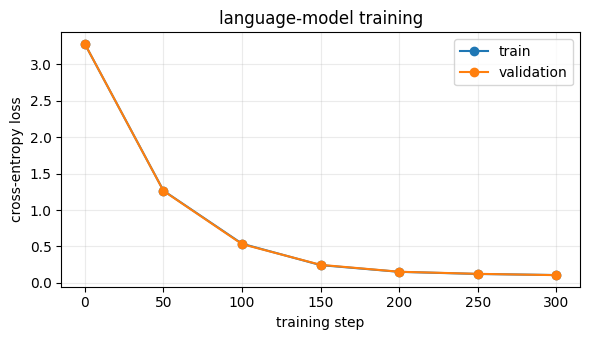

In [13]:
fig, ax = plt.subplots(figsize=(6, 3.5))
ax.plot(history["step"], history["train"], marker="o", label="train")
ax.plot(history["step"], history["val"], marker="o", label="validation")
ax.set_xlabel("training step")
ax.set_ylabel("cross-entropy loss")
ax.set_title("language-model training")
ax.grid(alpha=0.25)
ax.legend()
plt.tight_layout()
plt.show()

## 10. 自回归生成

训练时可以并行计算所有位置，是因为完整目标已知且 causal mask 防止信息泄漏。生成时未来 token 尚不存在，所以必须重复：

```text
当前上下文 -> 模型 -> 最后位置 logits -> 采样一个 token -> 追加到上下文
```

- `temperature < 1`：分布更尖锐，输出更保守；
- `temperature > 1`：分布更平坦，输出更多样也更随机；
- `top_k`：只保留得分最高的 k 个候选，再采样。

位置 embedding 只支持 `block_size` 个位置，因此生成时只把最近的 `block_size` 个 token 送入模型。这叫 context cropping，不是 KV cache。

In [14]:
@torch.no_grad()
def generate(
    model: DecoderOnlyTransformer,
    prompt: str,
    max_new_tokens: int,
    temperature: float = 1.0,
    top_k: int | None = None,
) -> str:
    if not prompt:
        raise ValueError("prompt must not be empty")
    if max_new_tokens < 0:
        raise ValueError("max_new_tokens must be non-negative")
    if temperature <= 0:
        raise ValueError("temperature must be positive")
    if top_k is not None and not 1 <= top_k <= model.vocab_size:
        raise ValueError(f"top_k must be between 1 and {model.vocab_size}")

    was_training = model.training
    model.eval()
    idx = torch.tensor([encode(prompt)], dtype=torch.long, device=device)

    for _ in range(max_new_tokens):
        context = idx[:, -model.block_size:]
        logits, _, _ = model(context)
        next_logits = logits[:, -1, :] / temperature
        if top_k is not None:
            threshold = torch.topk(next_logits, top_k).values[:, -1, None]
            next_logits = next_logits.masked_fill(next_logits < threshold, float("-inf"))
        probabilities = F.softmax(next_logits, dim=-1)
        next_token = torch.multinomial(probabilities, num_samples=1)
        idx = torch.cat((idx, next_token), dim=1)

    model.train(was_training)
    return decode(idx[0].cpu())


prompt = "the "
generated_text = generate(
    model,
    prompt=prompt,
    max_new_tokens=180,
    temperature=0.8,
    top_k=min(12, vocab_size),
)
assert generated_text.startswith(prompt)
assert len(generated_text) == len(prompt) + 180
print(generated_text)

the words and learns the rhythm.
atention lets each token look back at the tokens before it.
the moooon is bright, the night is calm, and the river moves slowly.
we build the transform


## 11. 如何测试训练好的模型

语言模型没有一个固定的“正确续写”，因此测试要同时回答两个问题：

1. **定性测试**：给定不同开头，模型能否生成像训练语料的文本？
2. **定量测试**：面对没有参与参数更新的数据，模型预测下一个字符的平均误差有多大？

测试前要调用 `model.eval()`。它会关闭 dropout，使相同模型参数下的评估更稳定。这里的 `generate()` 和 `estimate_loss()` 会临时切换模式，并在结束后恢复原状态。

### 11.1 使用多组提示词检查生成效果

下面的提示词都只包含训练词表中的字符。模型是字符级模型，所以提示词不必是完整单词；但只要包含大写字母、数字、中文等词表外字符，`encode()` 就会明确报错。

In [15]:
test_prompts = [
    "the ",
    "attention ",
    "the moon ",
    "we build ",
]

for test_prompt in test_prompts:
    result = generate(
        model,
        prompt=test_prompt,
        max_new_tokens=100,
        temperature=0.8,
        top_k=min(12, vocab_size),
    )
    assert result.startswith(test_prompt)
    assert len(result) == len(test_prompt) + 100
    print(f"prompt: {test_prompt!r}")
    print(result)
    print("-" * 60)

prompt: 'the '
the rans the rhythm.
attention lets each token look back athe token look back at the tokens before it.
t
------------------------------------------------------------
prompt: 'attention '
attention lets each token look back at the tokens before it.
the mooon is bright, the night is calm, and the r
------------------------------------------------------------
prompt: 'the moon '
the moon is bright, the night is calm, and the ricts character, the story grows by one.
the little model read
------------------------------------------------------------


prompt: 'we build '
we build the transformer one careful step at a time.
when the model predicts a character, the story grows by 
------------------------------------------------------------


检查输出时不要只看某一个字符是否“答对”，而要观察：

- 是否出现训练语料中的拼写、单词和句式；
- 是否能在较长范围内保持局部连贯；
- 多个提示词是否得到与各自上下文相符的续写；
- 是否只是逐字背诵训练语料。

### 11.2 比较采样参数

模型输出的是下一个字符的概率分布，`temperature` 和 `top_k` 只改变如何从这个分布中采样，不会改变已经训练好的参数。为了公平比较，下面在每次生成前设置同一个随机种子。

In [16]:
for test_temperature in (0.3, 0.8, 1.2):
    torch.manual_seed(7)
    result = generate(
        model,
        prompt="attention ",
        max_new_tokens=100,
        temperature=test_temperature,
        top_k=min(12, vocab_size),
    )
    print(f"temperature={test_temperature}")
    print(result)
    print()


temperature=0.3
attention lets each token look back at the tokens before it.
the mooon is bright, the night is calm, and the r

temperature=0.8
attention lets each token look back athe tokens before it.
the moooon is bright, the night is calm, and the ri

temperature=1.2
attention lets each token look back athe tokens before it.
the ittle model predicts a character, the story gro



通常 `temperature=0.3` 更保守、更容易重复高概率模式；`1.2` 更多样，但也更容易产生拼写错误。生成质量具有随机性，因此不能替代验证集指标。

### 11.3 用验证集 loss 和 perplexity 定量评估

`estimate_loss()` 会从训练集和验证集分别抽取多批数据，计算平均交叉熵：

- **validation loss** 越低，说明模型给真实下一个字符分配的概率越高；
- **perplexity（困惑度）** 是 `exp(loss)`，可以粗略理解为模型每一步面对的“有效候选数量”，越接近 1 越好；
- 训练 loss 很低而验证 loss 明显更高，通常意味着过拟合。

注意：这里的验证集来自同一段重复语料，指标只能衡量模型是否学会了这份小语料，不能证明模型具备通用语言能力。

In [17]:
test_losses = estimate_loss()
test_perplexity = math.exp(test_losses["val"])

assert math.isfinite(test_losses["train"])
assert math.isfinite(test_losses["val"])
assert test_perplexity >= 1.0

print(f"train loss:          {test_losses['train']:.4f}")
print(f"validation loss:     {test_losses['val']:.4f}")
print(f"validation perplexity: {test_perplexity:.4f}")

train loss:          0.1073
validation loss:     0.1051
validation perplexity: 1.1108


### 11.4 评估一段指定文本

有时我们希望知道模型对某段文本有多“意外”。下一个函数把文本切成不超过 `block_size` 的片段，让每个字符预测它后面的字符，并按预测字符数量计算加权平均 loss。

这不是独立测试集：下面的句子来自内置语料，只用于演示评估方法。实际项目应预留一份训练期间从未使用过、且来源具有代表性的 test set，最终只评估一次。

In [18]:
@torch.no_grad()
def evaluate_text(model: DecoderOnlyTransformer, text_value: str) -> dict[str, float]:
    token_ids = torch.tensor(encode(text_value), dtype=torch.long, device=device)
    if token_ids.numel() < 2:
        raise ValueError("text must contain at least two characters")

    was_training = model.training
    model.eval()
    weighted_loss = 0.0
    token_count = 0

    for start in range(0, token_ids.numel() - 1, model.block_size):
        chunk = token_ids[start : start + model.block_size + 1]
        inputs = chunk[:-1].unsqueeze(0)
        targets = chunk[1:].unsqueeze(0)
        _, chunk_loss, _ = model(inputs, targets)
        predicted_tokens = targets.numel()
        weighted_loss += chunk_loss.item() * predicted_tokens
        token_count += predicted_tokens

    model.train(was_training)
    average_loss = weighted_loss / token_count
    return {
        "loss": average_loss,
        "perplexity": math.exp(average_loss),
        "predicted_tokens": token_count,
    }


sample_test_text = "attention lets each token look back at the tokens before it."
text_metrics = evaluate_text(model, sample_test_text)

assert math.isfinite(text_metrics["loss"])
assert text_metrics["predicted_tokens"] == len(sample_test_text) - 1

print("text:", sample_test_text)
print(f"predicted tokens: {text_metrics['predicted_tokens']}")
print(f"loss:             {text_metrics['loss']:.4f}")
print(f"perplexity:       {text_metrics['perplexity']:.4f}")

text: attention lets each token look back at the tokens before it.
predicted tokens: 59
loss:             0.2277
perplexity:       1.2558


### 测试结论应该怎样写？

一次完整的小模型测试至少记录：模型和语料版本、测试文本来源、loss/perplexity、生成参数，以及几组原始生成样本。不要只挑最好的一条输出。

本例很容易取得很低的验证 loss，因为语料只有几句话并被重复了 80 次，训练集和验证集的模式高度相似。它适合验证 Transformer 实现是否正确，不适合衡量真实世界的语言能力。

## 12. 查看模型学到的注意力

下面取一个短提示词，读取最后一个 Transformer block 的第一个 head。图中的：

- 行是 Query token，也就是“谁在看”；
- 列是 Key token，也就是“看向谁”；
- 颜色越亮表示注意力权重越高；
- 对角线上方必须全为 0，因为那里是未来位置。

注意力权重可以帮助检查信息流，但不能简单等同于模型的完整解释或因果贡献。

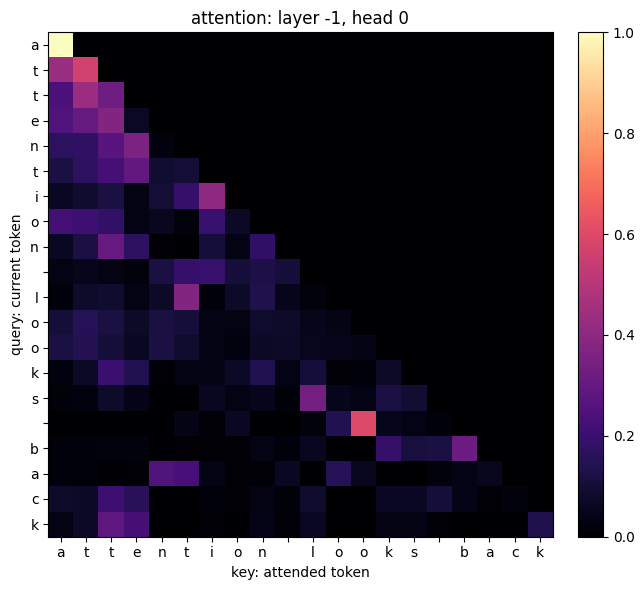

In [19]:
def plot_attention(model, text_value: str, layer: int = -1, head: int = 0):
    if len(text_value) > model.block_size:
        raise ValueError("text is longer than block_size")
    if not -len(model.blocks) <= layer < len(model.blocks):
        raise ValueError("layer index is out of range")
    if not 0 <= head < model.blocks[0].attention.n_head:
        raise ValueError("head index is out of range")

    was_training = model.training
    model.eval()
    idx = torch.tensor([encode(text_value)], dtype=torch.long, device=device)
    with torch.inference_mode():
        _, _, layers = model(idx, return_attention=True)
    model.train(was_training)

    matrix = layers[layer][0, head].cpu()
    tokens = list(text_value)
    fig, ax = plt.subplots(figsize=(7, 6))
    image = ax.imshow(matrix, cmap="magma", vmin=0, vmax=matrix.max().item())
    ax.set_xticks(range(len(tokens)), tokens)
    ax.set_yticks(range(len(tokens)), tokens)
    ax.set_xlabel("key: attended token")
    ax.set_ylabel("query: current token")
    ax.set_title(f"attention: layer {layer}, head {head}")
    fig.colorbar(image, ax=ax, fraction=0.046, pad=0.04)
    plt.tight_layout()
    plt.show()
    return matrix


attention_text = "attention looks back"
learned_attention = plot_attention(model, attention_text, layer=-1, head=0)
future = torch.triu(
    torch.ones(len(attention_text), len(attention_text), dtype=torch.bool),
    diagonal=1,
)
assert torch.all(learned_attention[future] == 0)
assert torch.allclose(
    learned_attention.sum(dim=-1),
    torch.ones(len(attention_text)),
    atol=1e-6,
)

## 13. 总结：完整执行路径

```text
原始文本
  -> 字符级 encode
token ids (B,T)
  -> token embedding + position embedding
x (B,T,C)
  -> LayerNorm
  -> Q,K,V projection
q,k,v (B,H,T,D)
  -> q @ k^T / sqrt(D)
scores (B,H,T,T)
  -> causal mask -> softmax
attention (B,H,T,T)
  -> attention @ v -> 合并 heads -> projection
  -> residual connection
  -> LayerNorm -> FFN -> residual connection
  -> 重复多个 Transformer blocks
  -> final LayerNorm -> lm_head
logits (B,T,vocab_size)
  -> cross entropy / sampling
损失或下一个 token
```

## 常见问题定位

| 现象 | 优先检查 |
|---|---|
| 矩阵乘法形状错误 | `transpose(1,2)`、head 拆分顺序、`C % H == 0` |
| 模型能偷看答案 | mask 是否在 softmax 前应用，是否为下三角 |
| attention 行和不是 1 | softmax 是否沿最后一维；训练时是否查看了 dropout 后权重 |
| loss 维度错误 | logits 是否变成 `(B*T,V)`，targets 是否变成 `(B*T)` |
| 生成超过上下文时报错 | 是否裁剪为最近 `block_size` 个 token |
| 生成内容杂乱 | 训练不足、语料太小、temperature 太高或 tokenizer 太细 |

## 复习问题

1. 为什么 causal mask 使训练可以并行，却没有让生成也并行？
2. 为什么缩放因子是 $\sqrt{D}$ 而不是 $\sqrt{C}$？
3. `nn.Embedding` 与 one-hot 向量乘权重矩阵有什么关系？
4. 多个 attention head 的结果为什么需要重新拼接并投影？
5. pre-norm 中 LayerNorm 位于残差分支的什么位置？
6. attention map 为什么不能直接当作完整的模型解释？

## 小练习

1. **关闭 causal mask**：预期训练 loss 会异常快速下降，但模型训练时偷看未来，生成质量不会因此可靠提升。
2. **把 `n_head` 改为 8**：`D` 从 16 变为 8，attention 形状中的 head 维变为 8，总 embedding 维仍为 64。
3. **删除 position embedding**：模型仍可运行，但更难区分相同字符在不同位置的作用。
4. **比较不同 temperature**：固定 prompt，分别使用 0.5、1.0、1.5；预期随机性逐渐增加。
5. **扩大语料和上下文**：替换 `base_text` 并增大 `block_size`，同时观察训练时间和 attention 矩阵大小。注意 attention 的时间与显存复杂度约为 $O(T^2)$。

下一步可以继续学习：权重共享、RoPE、RMSNorm、SwiGLU、KV cache、BPE tokenizer，以及真正的大规模训练流程。